# Experiment 2: Heterogenous Tissue
**Drug Modeled:** Gefitinib

**Condition Tested:** Diffusion through dense, heterogenous tumor tissue

**Research Question:** How does tissue structure influence drug delivery?

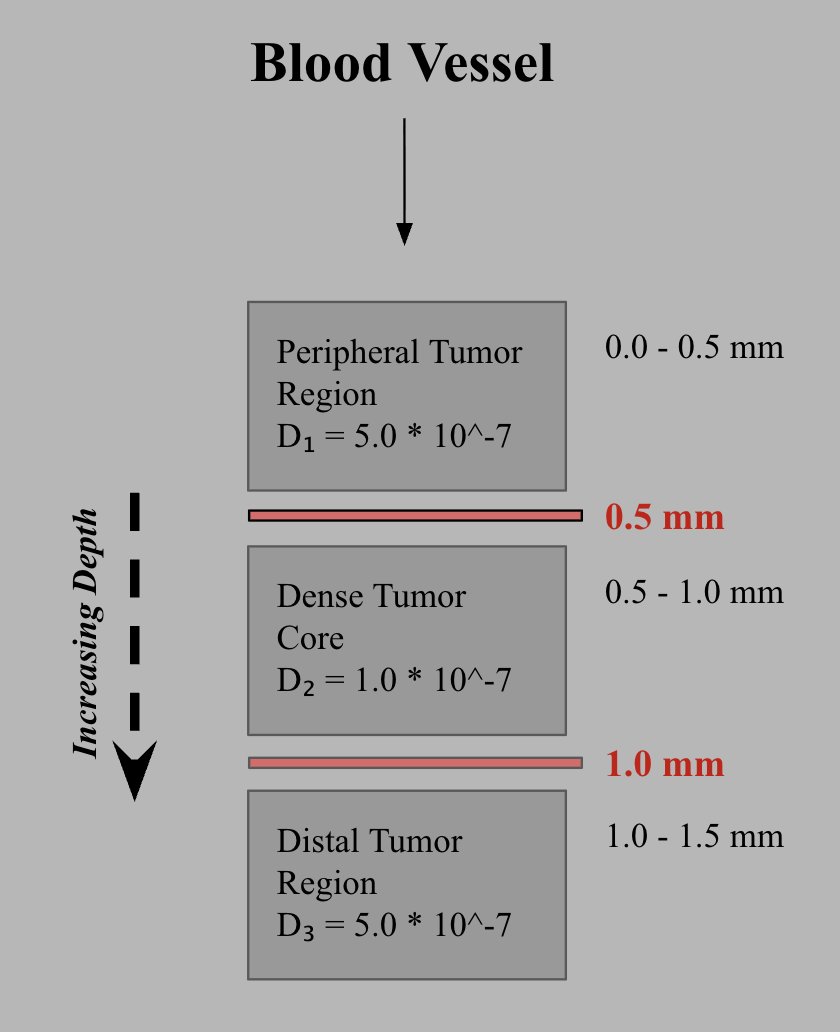

In [51]:
from IPython.display import Image

Image('figures/exp02_layered_tissue_schematic.png', width = 500)

## Figure 2A

**Figure 2A.** Schematic representation of the heterogeneous tissue model governing this experiment.

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Effective diffusion coefficient for gefitinib in tumor tissue
D = 5e-7            # cm^2 /s

# Normalized source concentration
# Relative concentration used to study spatial gradients
C0 = 1.0            # arbitrary units

# Tissue depth range
# 0-2 mm into tumor tissue
x = np.linspace(0, 0.2, 1000)       # cm

# Single time point
# 1 hour after drug exposure
t = 3600            # seconds

In [53]:
import numpy as np

# Analytical Solution to Fick's Second Law

# Fundamental solution of the 1D diffusion equation

# Represents spatial redistribution of drug from an initial source

normalization = 1 / np.sqrt(4 * np.pi * D * t)

# Gefitinib concentration profile as a function of depth

C = C0 * normalization * np.exp(-(x**2) / (4 * D * t))

ny = 100

C_heatmap = np.tile(C, (ny, 1))

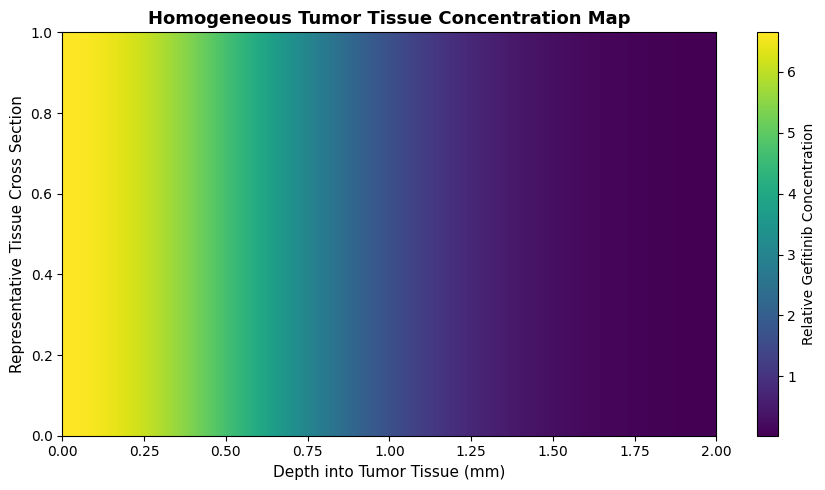

In [54]:
import os
os.makedirs('figures', exist_ok=True)

# Plot

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(
    C_heatmap,
    aspect='auto',
    cmap='viridis',
    origin='lower',
    extent=[0, x.max() * 10, 0, 1]
)

# Labels and formatting
ax.set_title(
    'Homogeneous Tumor Tissue Concentration Map',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel(
    'Depth into Tumor Tissue (mm)',
    fontsize=11
)

ax.set_ylabel(
    'Representative Tissue Cross Section',
    fontsize=11
)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Relative Gefitinib Concentration')

plt.tight_layout()

plt.savefig(
    'figures/exp02_homogeneous_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Figure 2B

**Figure 2B.** Simulated gefitinib concentration distribution in homogeneous tumor tissue. Drug concentration decreases smoothly with increasing depth, producing a continuous concentration gradient in the absence of structural heterogeneity.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# spatial grid

L = 0.2
nx = 200

x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# total running time (s)
T = 86400

# Layer boundaries (cm)
boundary_1 = 0.05   # 0.5 mm
boundary_2 = 0.10   # 1.0 mm

# Diffusion coefficients for each layer (cm^2/s)
D1 = 5e-7
D2 = 1e-7
D3 = 5e-7

# Saving buffer
save_every = 100

In [ ]:
C = np.zeros(nx)
D = np.zeros(nx)

# initial bolus at left side
C[0:5] = 1.0

for i, xi in enumerate(x):
    if xi < boundary_1:
        D[i] = D1
    elif xi < boundary_2:
        D[i] = D2
    else:
        D[i] = D3

D_max = np.max(D)
dt = 0.4 * dx**2 / D_max

# Number of timesteps needed
nt = int(np.ceil(T / dt))

print("dt =", dt)
print("nt =", nt)

# Drug source at tissue surface
C[0] = 1.0

C_history = np.zeros((nt, nx))
C_history[0] = C.copy()

for n in range(1, nt):
    C_new = C.copy()

    for i in range(1, nx - 1):

        # diffusivity at interfaces
        D_right = 0.5 * (D[i] + D[i + 1])
        D_left  = 0.5 * (D[i] + D[i - 1])

        # fluxes
        J_right = D_right * (C[i + 1] - C[i])
        J_left  = D_left  * (C[i] - C[i - 1])

        # update
        C_new[i] = C[i] + dt * (J_right - J_left) / dx**2

    # No-flux boundary at deepest edge
    C_new[-1] = C_new[-2]

    # Constant concentration source at surface
    C_new[0] = 1.0

    C = C_new
    C_history[n] = C

dt = 0.8080604025150881
nt = 106923


KeyboardInterrupt: 

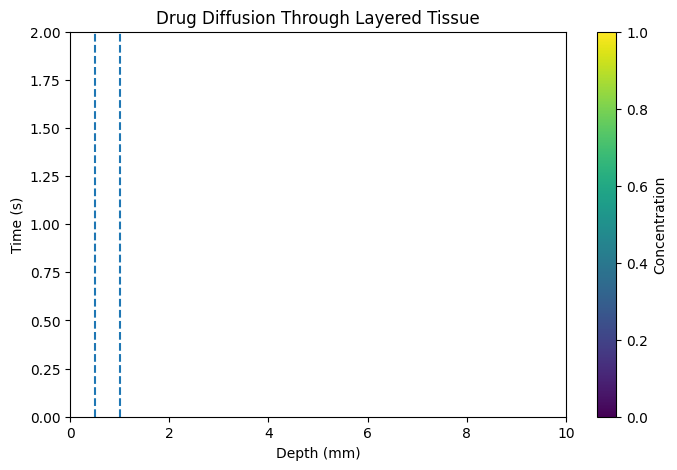

In [ ]:
plt.figure(figsize=(8, 5))

plt.imshow(

    C_history,

    aspect='auto',

    origin='lower',

    extent=[0, L * 10, 0, T]

)

plt.colorbar(label='Concentration')

plt.xlabel('Depth (mm)')
plt.ylabel('Time (s)')

plt.title('Drug Diffusion Through Layered Tissue')

plt.axvline(boundary_1 * 10, linestyle='--')
plt.axvline(boundary_2 * 10, linestyle='--')

plt.savefig(
    'figures/exp02_heterogeneous_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()